# 7095 Team Project
## A Big Data Pipeline for Walmart Sales Forecasting


Wei Liming 25421751

Ke Linyao 25407694

Huo Weijia 25407651

Xu Hao 25443658

Zhang Hongyang 25450816


### 1. Data Preprocessing & Visulization
The data is retrieved at Kaggle[https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast].
The dataset comprises four CSV files: train, test , features, and stores.

#### 1.1 Import necessary libraries

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
%matplotlib inline

#### 1.2 Load data

In [16]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
features = pd.read_csv('data/features.csv')
stores = pd.read_csv('data/stores.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Features shape:", features.shape)
print("Stores shape:", stores.shape)

Train shape: (421570, 5)
Test shape: (115064, 4)
Features shape: (8190, 12)
Stores shape: (45, 3)


#### 1.3 Preprocess dates

In [17]:
# Convert date columns to datetime
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])
features['Date'] = pd.to_datetime(features['Date'])

# Handle missing markdown values in features.csv

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
cutoff = pd.Timestamp('2011-11-01')   # Markdown data becomes available after Nov 2011
after_nov_2011 = features['Date'] >= cutoff

# Create indicator columns (1 if original value was not NA, else 0)
for col in markdown_cols:
    ind_col = f'has{col}'
    features[ind_col] = (~features[col].isna()).astype(int)
    # Before Nov 2011, set indicator to 0 (no data available)
    features.loc[~after_nov_2011, ind_col] = 0
    # Replace NA with 0
    features[col] = features[col].fillna(0)

print("Features after markdown handling:")
features.head()

Features after markdown handling:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,hasMarkDown1,hasMarkDown2,hasMarkDown3,hasMarkDown4,hasMarkDown5
0,1,2010-02-05,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,0,0,0,0,0
1,1,2010-02-12,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,True,0,0,0,0,0
2,1,2010-02-19,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,False,0,0,0,0,0
3,1,2010-02-26,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,False,0,0,0,0,0
4,1,2010-03-05,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,False,0,0,0,0,0


The markdown fields are set to 0 for missing values because a missing value indicates either no promotion or data unavailability; using 0 preserves the additive nature of the features. The indicator columns (hasMarkDown1 etc.) capture whether a markdown actually occurred, while rows before November 2011 have indicators forced to 0 because markdown data was not tracked during that period.

#### 1.4 Merge train with features and stores


In [18]:
# Merge train with features on Store and Date
merged = pd.merge(train, features, on=['Store', 'Date'], how='left')
# Merge with stores on Store
merged = pd.merge(merged, stores, on='Store', how='left')
print("Merged data shape:", merged.shape)

Merged data shape: (421570, 22)


#### 1.5 Extract temporal features

In [19]:
merged['Year'] = merged['Date'].dt.year
merged['Month'] = merged['Date'].dt.month
merged['Week'] = merged['Date'].dt.isocalendar().week
print("Merged data sample:")
merged.head()

Merged data sample:


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,hasMarkDown1,hasMarkDown2,hasMarkDown3,hasMarkDown4,hasMarkDown5,Type,Size,Year,Month,Week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,0,0,0,0,0,A,151315,2010,2,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,True,0,0,0,0,0,A,151315,2010,2,6
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,False,0,0,0,0,0,A,151315,2010,2,7
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,False,0,0,0,0,0,A,151315,2010,2,8
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,False,0,0,0,0,0,A,151315,2010,3,9


#### 1.6 Outlier detection using IQR

In [20]:
Q1 = merged['Weekly_Sales'].quantile(0.25)
Q3 = merged['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = merged[(merged['Weekly_Sales'] < lower_bound) | (merged['Weekly_Sales'] > upper_bound)]
print(f"Number of outliers in Weekly_Sales: {len(outliers)}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(merged.describe())

Number of outliers in Weekly_Sales: 35521
Lower bound: -25109.65, Upper bound: 47395.16
               Store           Dept                           Date  \
count  421570.000000  421570.000000                         421570   
mean       22.200546      44.260317  2011-06-18 08:30:31.963375104   
min         1.000000       1.000000            2010-02-05 00:00:00   
25%        11.000000      18.000000            2010-10-08 00:00:00   
50%        22.000000      37.000000            2011-06-17 00:00:00   
75%        33.000000      74.000000            2012-02-24 00:00:00   
max        45.000000      99.000000            2012-10-26 00:00:00   
std        12.785297      30.492054                            NaN   

        Weekly_Sales    Temperature     Fuel_Price      MarkDown1  \
count  421570.000000  421570.000000  421570.000000  421570.000000   
mean    15981.258123      60.090059       3.361027    2590.074819   
min     -4988.940000      -2.060000       2.472000       0.000000   
25%  

#### 1.7 Correlation heatmap for numeric features

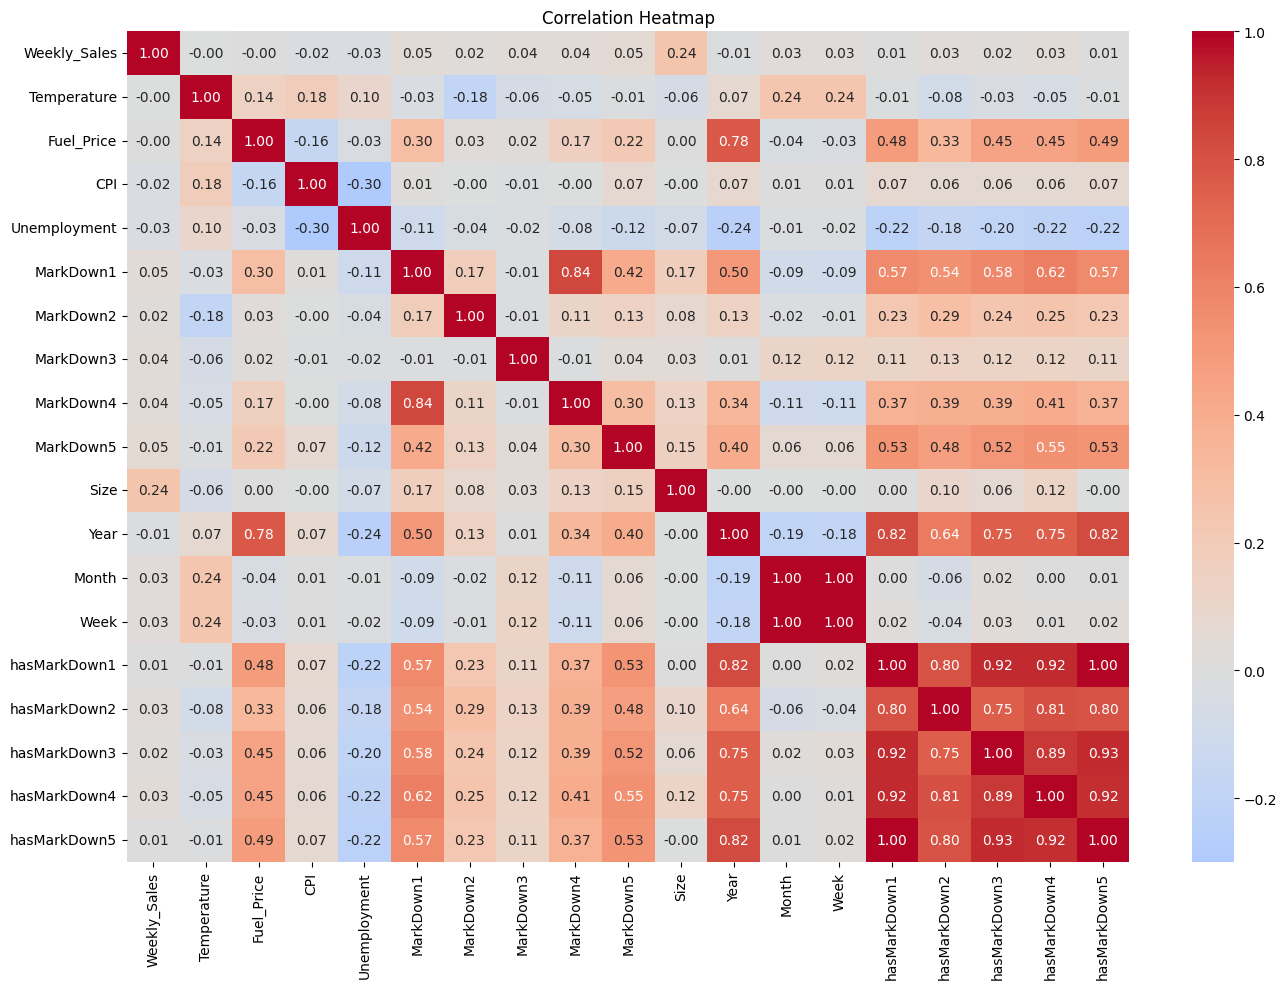

In [21]:
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
                'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
                'Size', 'Year', 'Month', 'Week']
# Add indicator columns if desired
indicator_cols = ['hasMarkDown1', 'hasMarkDown2', 'hasMarkDown3', 'hasMarkDown4', 'hasMarkDown5']
numeric_cols += indicator_cols

# Compute correlation matrix
corr = merged[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

#### 1.8 Other Descriptive visualizations

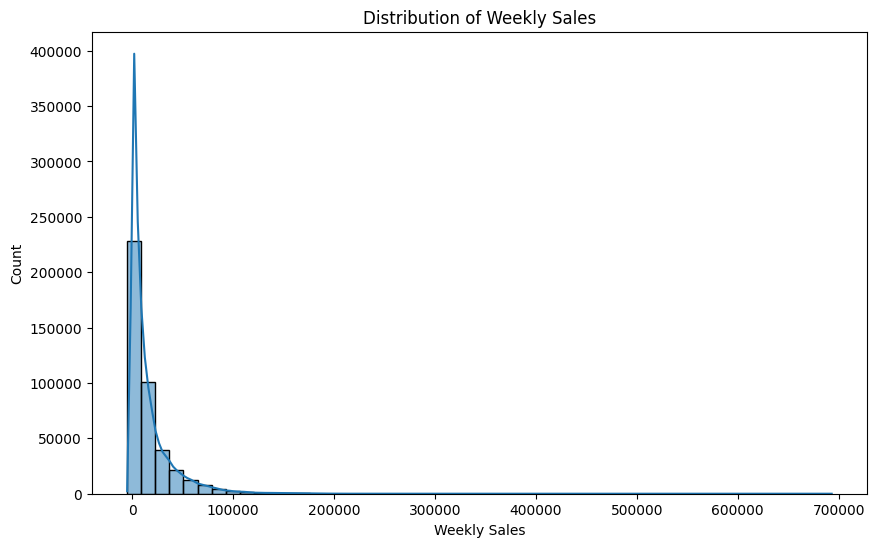

In [22]:
# Distribution of Weekly Sales
plt.figure(figsize=(10, 6))
sns.histplot(merged['Weekly_Sales'], bins=50, kde=True)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.show()

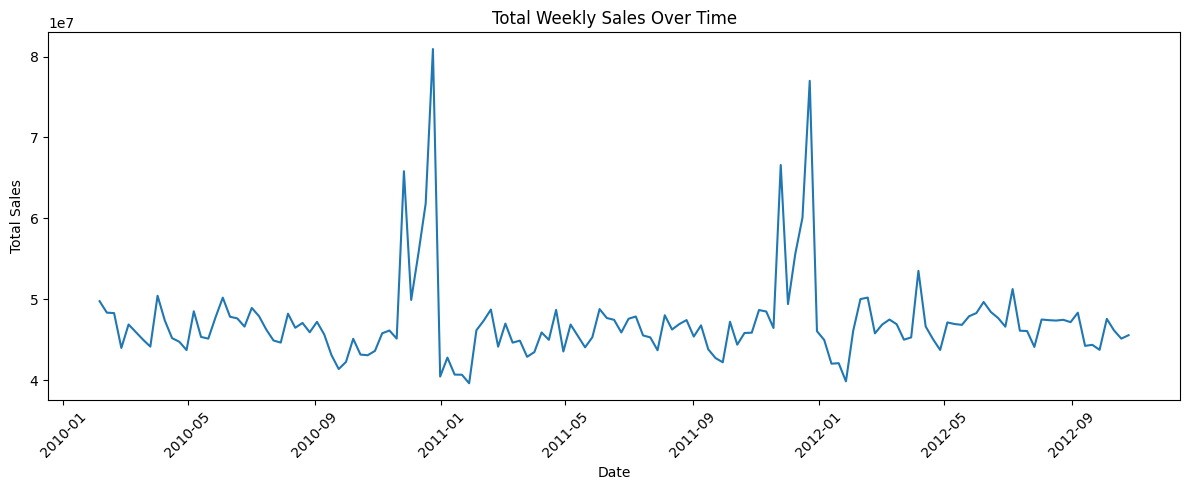

In [23]:
# Sales over time
daily_sales = merged.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(12, 5))
plt.plot(daily_sales['Date'], daily_sales['Weekly_Sales'])
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

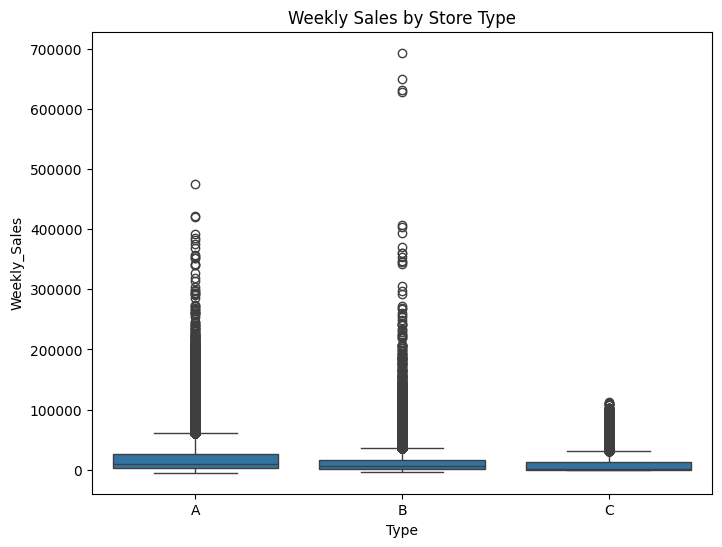

In [24]:
# Boxplot of sales by store type
plt.figure(figsize=(8, 6))
sns.boxplot(x='Type', y='Weekly_Sales', data=merged)
plt.title('Weekly Sales by Store Type')
plt.show()


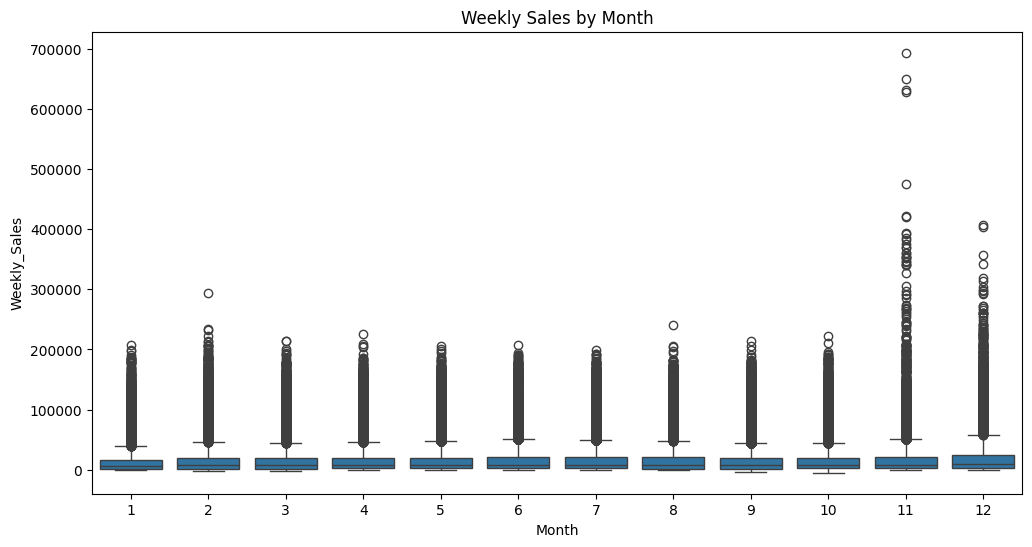

In [25]:
# Boxplot of sales by month 
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Weekly_Sales', data=merged)
plt.title('Weekly Sales by Month')
plt.show()

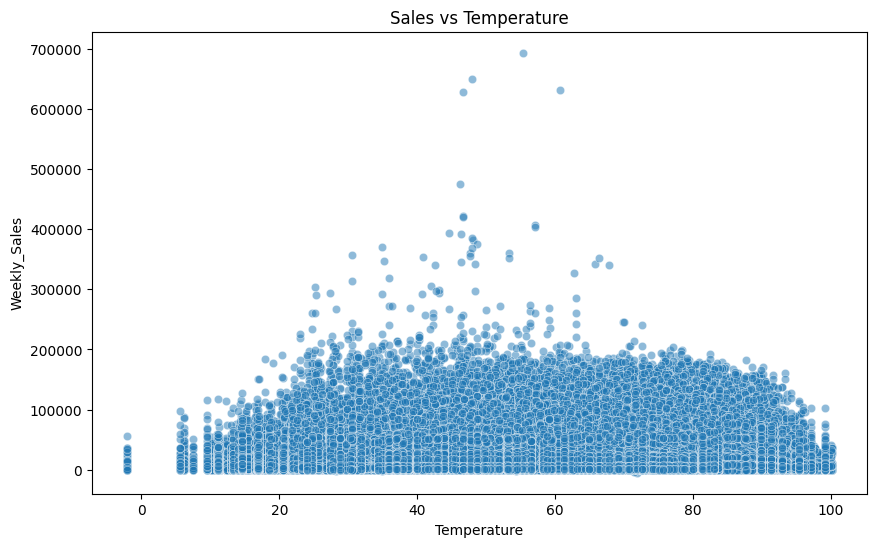

In [26]:
# Sales vs Temperature
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=merged, alpha=0.5)
plt.title('Sales vs Temperature')
plt.show()

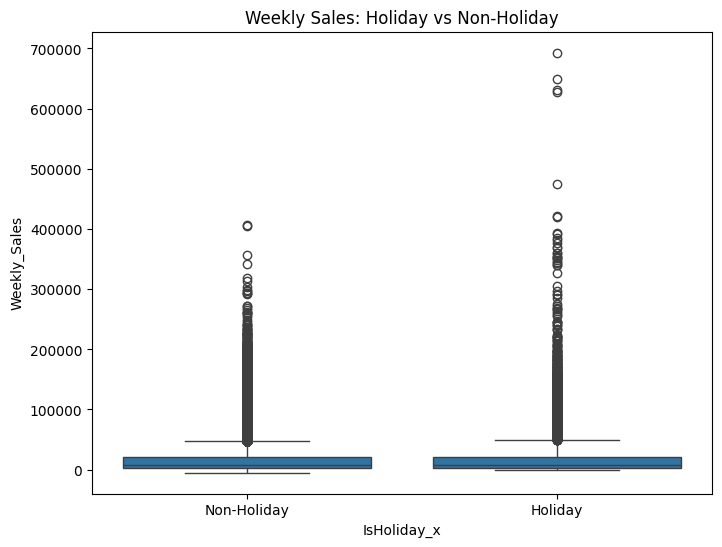

In [27]:
# Sales on holidays vs non-holidays
plt.figure(figsize=(8, 6))
sns.boxplot(x='IsHoliday_x', y='Weekly_Sales', data=merged)
plt.title('Weekly Sales: Holiday vs Non-Holiday')
plt.xticks([0,1], ['Non-Holiday', 'Holiday'])
plt.show()

#### 1.9 Output processed data

In [28]:
os.makedirs('data/preprocessed', exist_ok=True)

merged.to_csv('data/preprocessed/merged_train.csv', index=False)

features.to_csv('data/preprocessed/features_cleaned.csv', index=False)
stores.to_csv('data/preprocessed/stores.csv', index=False)

print("Preprocessed data saved to 'data/preprocessed/' directory.")

Preprocessed data saved to 'data/preprocessed/' directory.
